![headers_fraud-prev](headers_fraud-prev.jpg)


# Credit Card Fraud Detection & Risk Analysis

## Executive Summary

Credit card fraud presents a challenging classification problem because fraudulent transactions represent only a small fraction of overall transaction activity. In this dataset of **339,607 transactions**, approximately **0.52% were fraudulent**, making traditional accuracy an unreliable measure of model performance.

This project uses **SQL, Python, statistical analysis, and machine learning** to identify fraud patterns and develop a predictive model for detecting potentially fraudulent transactions.

Exploratory analysis found that **transaction amount and transaction timing were particularly important indicators of fraud**, while merchant category, geography, and customer characteristics provided additional information. Statistical testing also showed that customer age was significantly associated with fraud status, although the practical strength of the relationship was very weak.

Three classification approaches were evaluated: baseline logistic regression, class-balanced logistic regression, and Random Forest. The **Random Forest substantially outperformed both logistic regression approaches**, achieving approximately **86.5% fraud recall, 50.3% precision, and a PR-AUC of 0.85** at the default classification threshold.

Threshold analysis was then used to translate model performance into an operational decision. A **0.60 probability threshold** is recommended as an initial operating point, identifying approximately **80.1% of fraudulent transactions** while increasing fraud precision to approximately **65.7%** and reducing false-positive alerts.

Overall, the analysis demonstrates that effective fraud detection requires balancing predictive performance with the business costs of missed fraud, false-positive alerts, customer friction, and investigation capacity.

## Business Objective

A credit card company wants to improve its ability to identify fraudulent transactions while minimizing unnecessary alerts for legitimate customers.

The primary objectives of this analysis are to:

- Identify transaction and customer characteristics associated with fraudulent activity.
- Determine whether meaningful fraud patterns exist across transaction amount, merchant category, time, geography, and customer demographics.
- Develop and compare machine-learning models for fraud detection.
- Evaluate model performance using metrics appropriate for a highly imbalanced classification problem.
- Recommend a classification threshold that balances fraud detection with false-positive risk.
- Translate the analytical findings into actionable fraud-monitoring recommendations.

## Technical Approach

The analysis follows an end-to-end analytics workflow:

**Data Exploration — SQL & Python**  
SQL aggregation and Python were used to examine transaction volume, fraud frequency, transaction amounts, merchant categories, geographic patterns, transaction timing, and customer characteristics.

**Statistical Analysis — Python / SciPy**  
Statistical testing was used to evaluate whether observed relationships were statistically meaningful. Effect-size measures were also considered to distinguish statistical significance from practical importance.

**Feature Engineering — Pandas**  
Transaction timestamps and customer information were transformed into model-ready features including transaction hour, day of week, and customer age.

**Predictive Modeling — Scikit-learn**  
Baseline logistic regression, class-balanced logistic regression, and Random Forest classification models were developed and compared.

**Model Evaluation**  
Because fraud represents less than 1% of transactions, model evaluation emphasized recall, precision, F1 score, confusion matrices, and precision-recall performance rather than accuracy alone.

**Threshold Optimization**  
Random Forest probability thresholds were evaluated to understand the trade-off between detecting fraudulent transactions and generating false-positive alerts.

## Dataset Overview

The dataset contains credit card transactions from the western United States and includes information describing the transaction, merchant, customer, and fraud status.

Key variables used in the analysis include:

- **Transaction Date/Time** — date and time the transaction occurred
- **Merchant** — merchant associated with the transaction
- **Category** — merchant transaction category
- **Amount** — transaction value
- **City and State** — customer location
- **City Population** — population of the customer's city
- **Customer Job** — occupation of the cardholder
- **Date of Birth** — used to derive customer age
- **Transaction Number** — transaction identifier
- **Merchant Latitude/Longitude** — merchant geographic coordinates
- **Fraud Indicator (`is_fraud`)** — 1 for fraudulent transactions and 0 for legitimate transactions

The working dataset contains **339,607 transactions** and **15 original variables**.

## Data Dictionary

| transdatetrans_time | Transaction DateTime                        |
|---------------------|---------------------------------------------|
| merchant            | Merchant Name                               |
| category            | Category of Merchant                        |
| amt                 | Amount of Transaction                       |
| city                | City of Credit Card Holder                  |
| state               | State of Credit Card Holder                 |
| lat                 | Latitude Location of Purchase               |
| long                | Longitude Location of Purchase              |
| city_pop            | Credit Card Holder's City Population        |
| job                 | Job of Credit Card Holder                   |
| dob                 | Date of Birth of Credit Card Holder         |
| trans_num           | Transaction Number                          |
| merch_lat           | Latitude Location of Merchant               |
| merch_long          | Longitude Location of Merchant              |
| is_fraud            | Whether Transaction is Fraud (1) or Not (0) |

You can query the pre-loaded CSV file using SQL directly. Here’s a **sample query**, followed by some sample Python code and outputs:

In [42]:
SELECT * FROM 'credit_card_fraud.csv'
LIMIT 5


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44+00:00,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21 00:00:00+00:00,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51+00:00,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19 00:00:00+00:00,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27+00:00,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21 00:00:00+00:00,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03+00:00,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30 00:00:00+00:00,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32+00:00,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02 00:00:00+00:00,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [43]:
import pandas as pd 
ccf = pd.read_csv('credit_card_fraud.csv') 
ccf.head(100)

# Check the dimensions of the dataset
ccf.shape

# View column names and data types
ccf.info()

# Check for missing values
ccf.isnull().sum()

# Check for duplicate transactions
ccf.duplicated().sum()

# Summary statistics for numerical variables
ccf.describe()

# Count fraudulent and legitimate transactions
ccf['is_fraud'].value_counts()

# Calculate the percentage of fraudulent transactions
ccf['is_fraud'].value_counts(normalize=True) * 100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

is_fraud
0    99.475276
1     0.524724
Name: proportion, dtype: float64

In [44]:
SELECT
	COUNT(*) AS total_transactions,
	SUM(is_fraud) AS fraud_transactions,
	COUNT(*) - SUM(is_fraud) AS legitimate_transactions,
	ROUND(100.0 * SUM(is_fraud) / COUNT(*), 2) AS fraud_rate_pct
FROM 'credit_card_fraud.csv';

,total_transactions,fraud_transactions,legitimate_transactions,fraud_rate_pct
0,339607,1782.0,337825.0,0.52


In [45]:
SELECT
    category,
    COUNT(*) AS total_transactions,
    SUM(is_fraud) AS fraud_transactions,
    ROUND(
        100.0 * SUM(is_fraud) / COUNT(*),
        2
    ) AS fraud_rate_pct
FROM 'credit_card_fraud.csv'
GROUP BY category
ORDER BY fraud_rate_pct DESC;

,category,total_transactions,fraud_transactions,fraud_rate_pct
0,shopping_net,26379,381.0,1.44
1,grocery_pos,32732,433.0,1.32
2,misc_net,16898,217.0,1.28
3,shopping_pos,30329,187.0,0.62
4,gas_transport,35089,153.0,0.44
5,travel,10322,33.0,0.32
6,misc_pos,20024,62.0,0.31
7,grocery_net,11355,27.0,0.24
8,entertainment,24222,55.0,0.23
9,personal_care,24406,55.0,0.23


In [46]:
SELECT
    is_fraud,
    COUNT(*) AS transactions,
    ROUND(AVG(amt), 2) AS avg_transaction_amount,
    ROUND(MIN(amt), 2) AS min_transaction_amount,
    ROUND(MAX(amt), 2) AS max_transaction_amount
FROM 'credit_card_fraud.csv'
GROUP BY is_fraud;

,is_fraud,transactions,avg_transaction_amount,min_transaction_amount,max_transaction_amount
0,0,337825,68.22,1.00,28948.90
1,1,1782,518.07,1.78,1371.81


### Initial Fraud Analysis 

The dataset contains 339,607 credit card transactions, of which 1,782 were identified as fraudulent. Fraud therefore represents approximately 0.52% of all transactions, indicating a highly imbalanced dataset. Because fraudulent transactions are rare, model accuracy alone will not be an appropriate measure of predictive performance.

Fraud risk also varies considerably across merchant categories. Online shopping (`shopping_net`) had the highest observed fraud rate at 1.44%, followed by point-of-sale grocery purchases (`grocery_pos`) at 1.32% and miscellaneous online purchases (`misc_net`) at 1.28%. In comparison, the overall fraud rate across the dataset was only 0.52%.

Transaction amount also appears to be an important characteristic. Fraudulent transactions averaged $518.07, compared  with  $68.22 for legitimate transactions. However, legitimate transactions had a substantially higher maximum transaction value, indicating that transaction amount alone is unlikely to distinguish fraud reliably.

These initial findings suggest that merchant category and transaction amount may both provide useful predictive information when developing a fraud detection model.

In [47]:
SELECT
    CASE
        WHEN amt < 25 THEN 'Under $25'
        WHEN amt < 50 THEN '$25-$49.99'
        WHEN amt < 100 THEN '$50-$99.99'
        WHEN amt < 250 THEN '$100-$249.99'
        WHEN amt < 500 THEN '$250-$499.99'
        WHEN amt < 1000 THEN '$500-$999.99'
        ELSE '$1,000+'
    END AS amount_range,
    COUNT(*) AS total_transactions,
    SUM(is_fraud) AS fraud_transactions,
    ROUND(100.0 * SUM(is_fraud) / COUNT(*), 2) AS fraud_rate_pct
FROM 'credit_card_fraud.csv'
GROUP BY amount_range
ORDER BY
    MIN(amt);

,amount_range,total_transactions,fraud_transactions,fraud_rate_pct
0,Under $25,123103,372.0,0.30
1,$25-$49.99,55478,18.0,0.03
2,$50-$99.99,98139,17.0,0.02
3,$100-$249.99,52811,62.0,0.12
4,$250-$499.99,6032,476.0,7.89
5,$500-$999.99,2970,618.0,20.81
6,"$1,000+",1074,219.0,20.39


### Transaction Amount and Fraud Risk

Fraud risk varies substantially by transaction amount. Transactions below $250 had relatively low observed fraud rates, with each amount range remaining at or below 0.30%.

However, a sharp increase in fraud occurred among transactions of $250 or more. Transactions between $250 and $499.99 had a fraud rate of 7.89%, while transactions between $500 and $999.99 had the highest observed fraud rate at 20.81%. Transactions of $1,000 or more showed a similarly elevated fraud rate of 20.39%.

This suggests that transaction amount is an important predictor of fraudulent activity, particularly once transaction values reach approximately $250. However, transaction amount should not be used in isolation because legitimate high-value transactions are also present in the dataset.

In [48]:
SELECT
    category,
    CASE
        WHEN amt < 250 THEN 'Under $250'
        WHEN amt < 500 THEN '$250-$499.99'
        WHEN amt < 1000 THEN '$500-$999.99'
        ELSE '$1,000+'
    END AS amount_range,
    COUNT(*) AS total_transactions,
    SUM(is_fraud) AS fraud_transactions,
    ROUND(
        100.0 * SUM(is_fraud) / COUNT(*),
        2
    ) AS fraud_rate_pct
FROM 'credit_card_fraud.csv'
GROUP BY category, amount_range
HAVING COUNT(*) >= 50
ORDER BY fraud_rate_pct DESC;

,category,amount_range,total_transactions,fraud_transactions,fraud_rate_pct
0,grocery_pos,$250-$499.99,501,433.0,86.43
1,entertainment,$500-$999.99,51,36.0,70.59
2,shopping_net,"$1,000+",420,183.0,43.57
3,misc_net,$500-$999.99,567,213.0,37.57
4,shopping_net,$500-$999.99,739,198.0,26.79
5,shopping_pos,$500-$999.99,809,155.0,19.16
6,home,$250-$499.99,215,24.0,11.16
7,shopping_pos,"$1,000+",379,32.0,8.44
8,misc_net,"$1,000+",66,4.0,6.06
9,misc_pos,$500-$999.99,290,16.0,5.52


### Interaction Between Merchant Category and Transaction Amount

Analyzing transaction amount together with merchant category revealed substantially stronger fraud patterns than examining either variable independently.

The highest observed fraud rate occurred among grocery point-of-sale transactions between $250 and $499.99. Of 501 transactions in this group, 433 were fraudulent, resulting in an 86.43% fraud rate. This is dramatically higher than the overall dataset fraud rate of 0.52%.

Other high-risk combinations included entertainment transactions between $500 and $999.99 (70.59%), online shopping transactions of $1,000 or more (43.57%), and miscellaneous online transactions between $500 and $999.99 (37.57%).

These findings indicate that transaction amount and merchant category interact strongly in identifying potentially fraudulent activity. Rather than treating high transaction amounts as universally suspicious, a fraud detection system may benefit from evaluating transaction amounts within the context of the merchant category.

In [49]:
SELECT
    trans_date_trans_time,
    EXTRACT(
        HOUR FROM CAST(trans_date_trans_time AS TIMESTAMP)
    ) AS transaction_hour,
    is_fraud
FROM 'credit_card_fraud.csv'
LIMIT 10;

,trans_date_trans_time,transaction_hour,is_fraud
0,2019-01-01 00:00:44+00:00,0,0
1,2019-01-01 00:00:51+00:00,0,0
2,2019-01-01 00:07:27+00:00,0,0
3,2019-01-01 00:09:03+00:00,0,0
4,2019-01-01 00:21:32+00:00,0,0
5,2019-01-01 00:22:06+00:00,0,0
6,2019-01-01 00:22:18+00:00,0,0
7,2019-01-01 00:22:36+00:00,0,0
8,2019-01-01 00:31:51+00:00,0,0
9,2019-01-01 00:34:10+00:00,0,0


In [50]:
SELECT
    EXTRACT(
        HOUR FROM CAST(trans_date_trans_time AS TIMESTAMP)
    ) AS transaction_hour,
    COUNT(*) AS total_transactions,
    SUM(is_fraud) AS fraud_transactions,
    ROUND(
        100.0 * SUM(is_fraud) / COUNT(*),
        2
    ) AS fraud_rate_pct
FROM 'credit_card_fraud.csv'
GROUP BY transaction_hour
ORDER BY transaction_hour;

,transaction_hour,total_transactions,fraud_transactions,fraud_rate_pct
0,0,11039,168.0,1.52
1,1,11241,168.0,1.49
2,2,11019,140.0,1.27
3,3,11227,143.0,1.27
4,4,10904,7.0,0.06
5,5,11023,10.0,0.09
6,6,11145,7.0,0.06
7,7,11094,9.0,0.08
8,8,11123,12.0,0.11
9,9,10997,11.0,0.10


### Time-of-Day Fraud Patterns

Fraudulent activity is highly concentrated during late-night and early-morning hours. The highest observed fraud rate occurred at 11 PM (2.62%), closely followed by 10 PM (2.59%). Elevated fraud rates continued between midnight and 3 AM, ranging from 1.27% to 1.52%.

In contrast, fraud rates remained relatively low throughout most daytime and evening hours, generally ranging from approximately 0.05% to 0.13%.

Approximately 85.9% of all fraudulent transactions occurred between 10 PM and 3:59 AM, despite transactions occurring throughout the entire day.

These results suggest that transaction time is a potentially important predictor of fraudulent activity and that late-night transactions may warrant additional scrutiny when combined with other risk factors such as transaction amount and merchant category.

,transaction_hour,total_transactions,fraud_transactions,fraud_rate_pct
0,0,11039,168.0,1.52
1,1,11241,168.0,1.49
2,2,11019,140.0,1.27
3,3,11227,143.0,1.27
4,4,10904,7.0,0.06
5,5,11023,10.0,0.09
6,6,11145,7.0,0.06
7,7,11094,9.0,0.08
8,8,11123,12.0,0.11
9,9,10997,11.0,0.10


In [52]:
WITH customer_ages AS (
    SELECT
        *,
        DATE_DIFF(
            'year',
            CAST(dob AS DATE),
            CAST(trans_date_trans_time AS DATE)
        ) AS age
    FROM 'credit_card_fraud.csv'
)

SELECT
    CASE
        WHEN age < 25 THEN 'Under 25'
        WHEN age < 35 THEN '25-34'
        WHEN age < 45 THEN '35-44'
        WHEN age < 55 THEN '45-54'
        WHEN age < 65 THEN '55-64'
        ELSE '65+'
    END AS age_group,
    COUNT(*) AS total_transactions,
    SUM(is_fraud) AS fraud_transactions,
    ROUND(
        100.0 * SUM(is_fraud) / COUNT(*),
        2
    ) AS fraud_rate_pct
FROM customer_ages
GROUP BY age_group
ORDER BY
    MIN(age);

,age_group,total_transactions,fraud_transactions,fraud_rate_pct
0,Under 25,15783,140.0,0.89
1,25-34,69848,289.0,0.41
2,35-44,70882,229.0,0.32
3,45-54,84829,438.0,0.52
4,55-64,40711,300.0,0.74
5,65+,57554,386.0,0.67


### Customer Age and Fraud Risk

Fraud rates varied across customer age groups, but the results do not indicate a simple pattern in which fraud risk consistently increases with age.

Customers under age 25 had the highest observed fraud rate at 0.89%. Fraud rates declined among customers ages 25–34 (0.41%) and 35–44 (0.32%), before increasing among customers ages 45–54 (0.52%), 55–64 (0.74%), and 65 or older (0.67%).

These results suggest a nonlinear relationship between customer age and fraudulent activity. Both younger customers and older customers exhibited higher observed fraud rates than several middle-aged groups.

However, these descriptive differences alone do not establish that age is significantly associated with fraud. A statistical test is required before drawing conclusions about statistical significance.

In [53]:
SELECT
    state,
    COUNT(*) AS total_transactions,
    SUM(is_fraud) AS fraud_transactions,
    ROUND(
        100.0 * SUM(is_fraud) / COUNT(*),
        2
    ) AS fraud_rate_pct
FROM 'credit_card_fraud.csv'
GROUP BY state
HAVING COUNT(*) >= 100
ORDER BY fraud_rate_pct DESC;

,state,total_transactions,fraud_transactions,fraud_rate_pct
0,AK,2963,50.0,1.69
1,OR,26408,197.0,0.75
2,NE,34425,216.0,0.63
3,CO,19766,115.0,0.58
4,NM,23427,121.0,0.52
5,CA,80495,402.0,0.50
6,MO,54904,262.0,0.48
7,WA,27040,126.0,0.47
8,HI,3649,16.0,0.44
9,WY,27776,119.0,0.43


### Geographic Patterns in Fraud

Fraud rates varied across the western U.S. states represented in the dataset. Alaska had the highest observed fraud rate at 1.69%, more than three times the overall dataset fraud rate of 0.52%. Oregon (0.75%) and Nebraska (0.63%) had the next-highest observed rates.

Fraud volume and fraud rate, however, tell different stories. California recorded the largest number of fraudulent transactions (402), but its fraud rate was 0.50%, close to the overall dataset rate. Alaska recorded only 50 fraudulent transactions but had the highest proportion of fraudulent transactions.

These findings suggest that geographic information may provide useful predictive information, although differences in transaction volume and other characteristics across states should be considered before concluding that geography itself causes higher fraud risk.

,state,total_transactions,fraud_transactions,fraud_rate_pct
0,AK,2963,50.0,1.69
1,OR,26408,197.0,0.75
2,NE,34425,216.0,0.63
3,CO,19766,115.0,0.58
4,NM,23427,121.0,0.52
5,CA,80495,402.0,0.50
6,MO,54904,262.0,0.48
7,WA,27040,126.0,0.47
8,HI,3649,16.0,0.44
9,WY,27776,119.0,0.43


In [55]:
import pandas as pd
from scipy.stats import chi2_contingency

# Convert dates to datetime
ccf['trans_date_trans_time'] = pd.to_datetime(ccf['trans_date_trans_time'])
ccf['dob'] = pd.to_datetime(ccf['dob'])

# Calculate approximate age at transaction
ccf['age'] = (
    (ccf['trans_date_trans_time'] - ccf['dob']).dt.days / 365.25
).astype(int)

# Create age groups
ccf['age_group'] = pd.cut(
    ccf['age'],
    bins=[0, 24, 34, 44, 54, 64, float('inf')],
    labels=['Under 25', '25-34', '35-44', '45-54', '55-64', '65+']
)

# Create contingency table
age_fraud_table = pd.crosstab(
    ccf['age_group'],
    ccf['is_fraud']
)

age_fraud_table

is_fraud,0,1
age_group,,
Under 25,16333,149
25-34,73420,289
35-44,70622,241
45-54,82775,431
55-64,39712,325
65+,54963,347


In [56]:
# Chi-square test of independence
chi2, p_value, dof, expected = chi2_contingency(age_fraud_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 190.98
P-value: 0.000000
Degrees of freedom: 5


### Statistical Relationship Between Age and Fraud

A chi-square test of independence was conducted to determine whether customer age group and fraud status were associated.

The test produced a chi-square statistic of 190.98 with 5 degrees of freedom and a p-value below 0.001. Therefore, the null hypothesis of independence was rejected, providing evidence of a statistically significant association between customer age group and fraud status.

However, statistical significance does not necessarily indicate a strong practical relationship, particularly given the large sample size of the dataset. Cramér's V was therefore calculated to evaluate the strength of the association.

Cramér's V was 0.0237, indicating that although the relationship between age group and fraud status was statistically significant, the strength of the association was very weak.

Therefore, customer age may provide some predictive information, but age alone is unlikely to be a strong indicator of fraudulent activity. This contrasts with variables such as transaction amount, merchant category, and transaction time, which showed substantially stronger descriptive patterns during exploratory analysis.

In [57]:
import numpy as np

# Calculate Cramér's V
n = age_fraud_table.to_numpy().sum()
r, k = age_fraud_table.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, k - 1))
)

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.0237


## Fraud Prediction Model

The exploratory analysis identified several transaction characteristics associated with fraudulent activity, including transaction amount, merchant category, transaction time, geographic location, and customer age.

The next stage of the analysis develops classification models to determine whether these characteristics can be used collectively to identify fraudulent transactions.

Because fraud represents only approximately 0.52% of transactions, overall accuracy will not be treated as the primary measure of model performance. Greater emphasis will be placed on recall, precision, F1-score, and precision-recall performance, with particular attention given to minimizing false negatives.

In [58]:
# Create a separate DataFrame for modeling
model_df = ccf.copy()

# Extract transaction hour
model_df['transaction_hour'] = model_df['trans_date_trans_time'].dt.hour

# Extract day of week
model_df['day_of_week'] = model_df['trans_date_trans_time'].dt.dayofweek

# Add customer age
model_df['age'] = (
    (model_df['trans_date_trans_time'] - model_df['dob']).dt.days / 365.25
).astype(int)

# Select features for the initial model
model_df = model_df[
    [
        'amt',
        'category',
        'transaction_hour',
        'day_of_week',
        'age',
        'state',
        'city_pop',
        'is_fraud'
    ]
]

model_df.head()

model_df.info()

model_df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   amt               339607 non-null  float64
 1   category          339607 non-null  object 
 2   transaction_hour  339607 non-null  int32  
 3   day_of_week       339607 non-null  int32  
 4   age               339607 non-null  int64  
 5   state             339607 non-null  object 
 6   city_pop          339607 non-null  int64  
 7   is_fraud          339607 non-null  int64  
dtypes: float64(1), int32(2), int64(3), object(2)
memory usage: 18.1+ MB


amt                 0
category            0
transaction_hour    0
day_of_week         0
age                 0
state               0
city_pop            0
is_fraud            0
dtype: int64

In [59]:
# Separate predictors from target
X = model_df.drop(columns='is_fraud')
y = model_df['is_fraud']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining fraud rate:")
print(y_train.value_counts(normalize=True))

print("\nTesting fraud rate:")
print(y_test.value_counts(normalize=True))

Features shape: (339607, 7)
Target shape: (339607,)
Training rows: 271685
Testing rows: 67922

Training fraud rate:
is_fraud
0    0.994751
1    0.005249
Name: proportion, dtype: float64

Testing fraud rate:
is_fraud
0    0.994759
1    0.005241
Name: proportion, dtype: float64


In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define feature types
numeric_features = [
    'amt',
    'transaction_hour',
    'day_of_week',
    'age',
    'city_pop'
]

categorical_features = [
    'category',
    'state'
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['amt', 'transaction_hour', 'day_of_week',
                                  'age', 'city_pop']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['category', 'state'])])

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

In [62]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(
    "\nPR-AUC / Average Precision:",
    round(average_precision_score(y_test, y_prob), 4)
)

Classification Report:
              precision    recall  f1-score   support

           0     0.9948    0.9998    0.9973     67566
           1     0.0000    0.0000    0.0000       356

    accuracy                         0.9946     67922
   macro avg     0.4974    0.4999    0.4986     67922
weighted avg     0.9895    0.9946    0.9920     67922


Confusion Matrix:
[[67552    14]
 [  356     0]]

PR-AUC / Average Precision: 0.2025


### Baseline Logistic Regression Performance

The baseline logistic regression model achieved an overall accuracy of 99.46%. However, this result is misleading because fraudulent transactions represent only approximately 0.52% of the dataset.

Of the 356 fraudulent transactions contained in the test set, the baseline model correctly identified none, resulting in a fraud recall of 0.00%. The model classified nearly every transaction as legitimate.

The confusion matrix showed:

- 67,552 legitimate transactions correctly classified
- 14 legitimate transactions incorrectly flagged as fraud
- 356 fraudulent transactions incorrectly classified as legitimate
- 0 fraudulent transactions correctly identified

These results demonstrate why accuracy is an inappropriate primary performance metric for this highly imbalanced fraud detection problem. Despite achieving greater than 99% accuracy, the baseline model fails to accomplish the primary business objective of identifying fraudulent transactions.

The model achieved a PR-AUC (Average Precision) of 0.2025, suggesting that the predicted probabilities contain some useful ranking information even though the default classification threshold performs poorly.

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

balanced_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]
)

balanced_model.fit(X_train, y_train)

balanced_pred = balanced_model.predict(X_test)
balanced_prob = balanced_model.predict_proba(X_test)[:, 1]

print("Balanced Logistic Regression")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        balanced_pred,
        digits=4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        balanced_pred
    )
)

print(
    "\nPR-AUC / Average Precision:",
    round(
        average_precision_score(
            y_test,
            balanced_prob
        ),
        4
    )
)

Balanced Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0     0.9984    0.8899    0.9410     67566
           1     0.0334    0.7219    0.0639       356

    accuracy                         0.8891     67922
   macro avg     0.5159    0.8059    0.5024     67922
weighted avg     0.9933    0.8891    0.9364     67922


Confusion Matrix:
[[60130  7436]
 [   99   257]]

PR-AUC / Average Precision: 0.1289


### Cost-Sensitive Logistic Regression

To address the severe class imbalance, a second logistic regression model was trained using balanced class weights. This assigns greater importance to the minority fraud class during model training.

The balanced model identified 257 of the 356 fraudulent transactions in the test set, increasing fraud recall from 0.00% to 72.19%. Only 99 fraudulent transactions were missed, compared with 356 under the baseline model.

This improvement came with a substantial tradeoff. The model incorrectly flagged 7,436 legitimate transactions as fraudulent, reducing overall accuracy from 99.46% to 88.91% and producing a fraud precision of only 3.34%.

Additionally, average precision decreased from 0.2025 for the baseline model to 0.1289 for the balanced model. Therefore, while class weighting substantially improved fraud detection at the default classification threshold, it did not improve overall probability-ranking performance.

These results demonstrate the tradeoff between fraud recall and false-positive volume and indicate that the classification threshold should be evaluated explicitly rather than relying solely on the default 0.50 threshold.

In [66]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results = []

for threshold in thresholds:
    
    predictions = (balanced_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()
    
    threshold_results.append({
        'Threshold': threshold,
        'Fraud Recall': recall_score(y_test, predictions),
        'Fraud Precision': precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'F1 Score': f1_score(y_test, predictions),
        'Fraud Caught': tp,
        'Fraud Missed': fn,
        'False Positives': fp
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Threshold,Fraud Recall,Fraud Precision,F1 Score,Fraud Caught,Fraud Missed,False Positives
0,0.1,1.0000,0.0077,0.0152,356,0,46068
1,0.2,0.9466,0.0098,0.0194,337,19,34000
2,0.3,0.8708,0.0144,0.0284,310,46,21188
3,0.4,0.7472,0.0193,0.0376,266,90,13511
4,0.5,0.7219,0.0334,0.0639,257,99,7436
5,0.6,0.7022,0.0804,0.1443,250,106,2859
6,0.7,0.6798,0.1581,0.2565,242,114,1289
7,0.8,0.6039,0.2028,0.3037,215,141,845
8,0.9,0.4466,0.1963,0.2727,159,197,651


### Classification Threshold Analysis

Because the company prioritizes identifying fraudulent transactions and is willing to tolerate some false positives, multiple classification thresholds were evaluated rather than relying exclusively on the default 0.50 threshold.

Lower thresholds produced extremely high fraud recall but generated an impractical number of false positives. At a threshold of 0.10, the model identified all 356 fraudulent transactions but incorrectly flagged 46,068 legitimate transactions.

Increasing the threshold substantially improved this tradeoff. At a threshold of 0.70, the model identified 242 of 356 fraudulent transactions, corresponding to 67.98% recall, while generating 1,289 false positives. Compared with the default 0.50 threshold, this resulted in only 15 fewer detected fraud cases while eliminating 6,147 false-positive alerts.

A threshold of 0.80 produced the highest F1-score among the tested thresholds (0.3037) and reduced false positives further to 845, but fraud recall declined to 60.39%.

Therefore, 0.70 represents a reasonable candidate operating threshold for the balanced logistic regression model when greater emphasis is placed on fraud detection. However, the optimal threshold ultimately depends on the organization's relative costs of missed fraud and false-positive investigations.

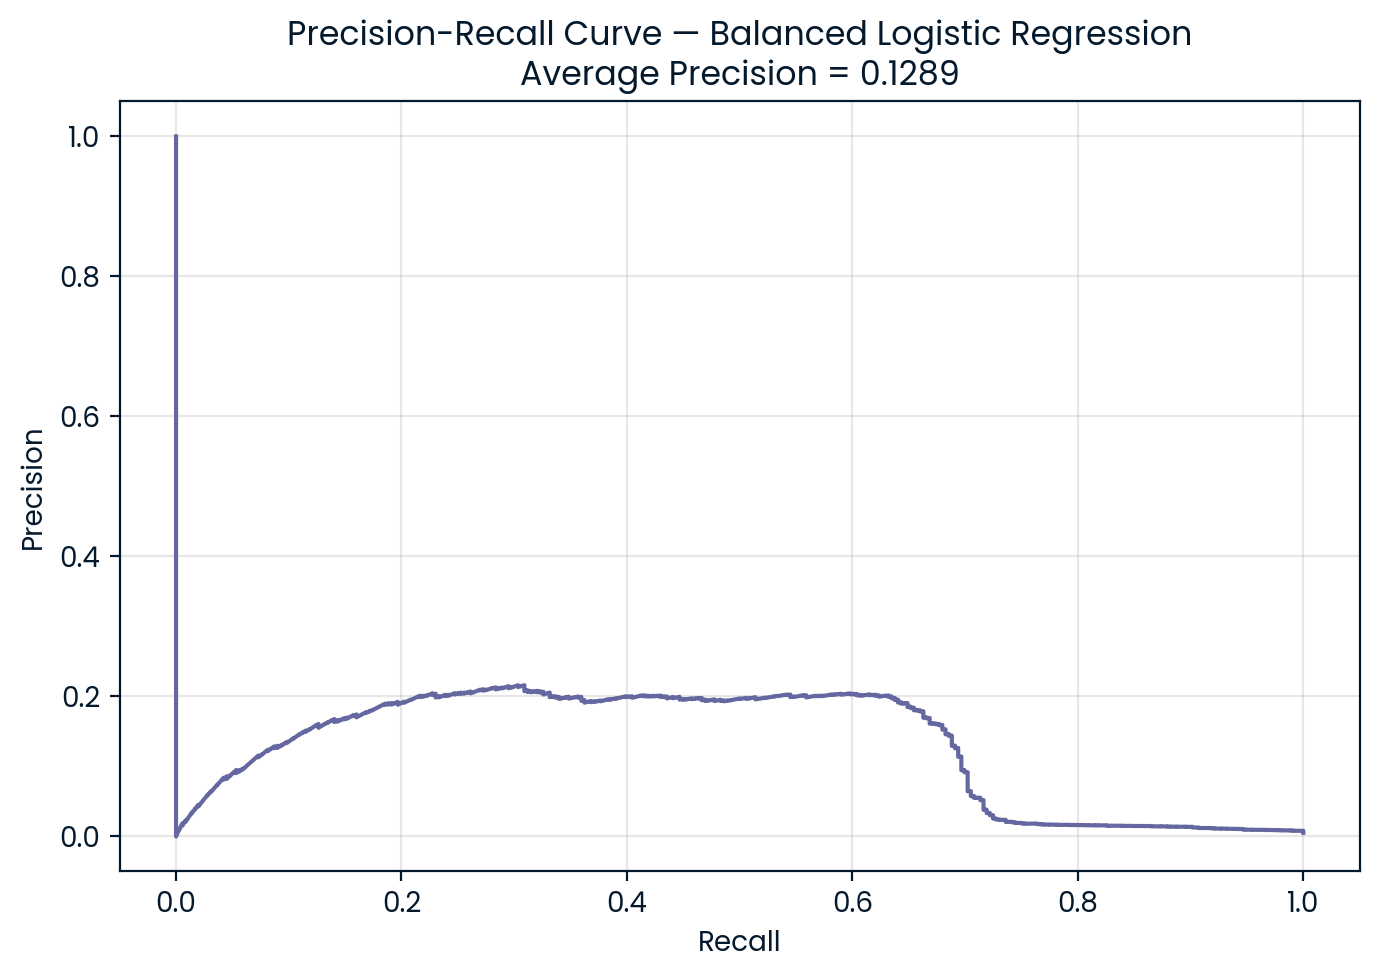

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    balanced_prob
)

ap = average_precision_score(y_test, balanced_prob)

plt.figure(figsize=(8, 5))

plt.plot(recall, precision)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(
    f'Precision-Recall Curve — Balanced Logistic Regression\n'
    f'Average Precision = {ap:.4f}'
)

plt.grid(alpha=0.3)
plt.show()

## Random Forest Model

The exploratory analysis revealed nonlinear fraud patterns, particularly interactions between transaction amount and merchant category. A Random Forest classifier was therefore evaluated as an alternative to logistic regression.

Unlike logistic regression, Random Forest models can capture nonlinear relationships and interactions between predictors without requiring those relationships to be specified manually.

Because fraudulent transactions represent a very small minority of the dataset, balanced class weights were again used during model training.

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amt', 'transaction_hour',
                                                   'day_of_week', 'age',
                                                   'city_pop']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'state'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        min_samples_leaf=5, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [69]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    digits=4
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test,
    rf_pred
))

print(
    "\nPR-AUC / Average Precision:",
    round(
        average_precision_score(y_test, rf_prob),
        4
    )
)

Random Forest

Classification Report:
              precision    recall  f1-score   support

           0     0.9993    0.9955    0.9974     67566
           1     0.5033    0.8652    0.6364       356

    accuracy                         0.9948     67922
   macro avg     0.7513    0.9303    0.8169     67922
weighted avg     0.9967    0.9948    0.9955     67922


Confusion Matrix:
[[67262   304]
 [   48   308]]

PR-AUC / Average Precision: 0.8483


### Random Forest Performance

The Random Forest model substantially outperformed both logistic regression models.

Of the 356 fraudulent transactions in the test set, the Random Forest correctly identified 308, producing a fraud recall of 86.52%. Only 48 fraudulent transactions were missed.

The model also achieved fraud precision of 50.33%, meaning approximately half of the transactions flagged as fraudulent were actually fraudulent. This represents a substantial improvement over the balanced logistic regression model, which achieved only 3.34% fraud precision.

The Random Forest generated 304 false-positive alerts while maintaining 99.48% overall accuracy. Its fraud F1-score increased to 0.6364, and average precision (PR-AUC) increased substantially to 0.8483.

These results indicate that the nonlinear relationships and interactions captured by the Random Forest provide substantially greater predictive value than the linear relationships modeled by logistic regression.

In [70]:
rf_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

rf_threshold_results = []

for threshold in rf_thresholds:
    
    predictions = (rf_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()
    
    rf_threshold_results.append({
        'Threshold': threshold,
        'Fraud Recall': recall_score(y_test, predictions),
        'Fraud Precision': precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        'F1 Score': f1_score(y_test, predictions),
        'Fraud Caught': tp,
        'Fraud Missed': fn,
        'False Positives': fp
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)

rf_threshold_df.round(4)

,Threshold,Fraud Recall,Fraud Precision,F1 Score,Fraud Caught,Fraud Missed,False Positives
0,0.1,0.9888,0.0379,0.0730,352,4,8937
1,0.2,0.9719,0.1153,0.2061,346,10,2655
2,0.3,0.9466,0.2242,0.3626,337,19,1166
3,0.4,0.9045,0.3515,0.5063,322,34,594
4,0.5,0.8652,0.5033,0.6364,308,48,304
5,0.6,0.8006,0.6567,0.7215,285,71,149
6,0.7,0.7556,0.8622,0.8054,269,87,43
7,0.8,0.6517,0.9469,0.7720,232,124,13
8,0.9,0.5056,0.9890,0.6691,180,176,2


### Random Forest Threshold Selection

Threshold analysis demonstrated that the Random Forest model provides considerable flexibility in balancing fraud detection against false-positive alerts.

At the default 0.50 threshold, the model identified 308 of 356 fraudulent transactions, resulting in 86.52% recall, 50.33% precision, and 304 false-positive alerts.

A threshold of 0.70 produced the highest F1-score (0.8054), with 75.56% recall and 86.22% precision while generating only 43 false positives. This threshold would be attractive when balancing fraud detection with the operational cost of investigating alerts.

However, the stated business objective prioritizes minimizing missed fraudulent transactions and indicates that false positives are relatively acceptable. For this reason, a threshold of 0.40 is recommended. At this threshold, the model detected 322 of 356 fraudulent transactions, achieving 90.45% recall while generating 594 false positives. Only 34 fraudulent transactions were missed.

The final operating threshold should ultimately be determined using the organization's actual financial cost of missed fraud relative to the cost of investigating false-positive alerts.

In [71]:
# Get feature names after preprocessing
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()

# Get Random Forest feature importances
importances = rf_model.named_steps['classifier'].feature_importances_

# Create feature importance table
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = (
    feature_importance_df
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.head(15)

,Feature,Importance
0,num__amt,0.544115
1,num__transaction_hour,0.212682
2,num__age,0.035953
3,num__city_pop,0.025506
4,cat__category_grocery_pos,0.024666
5,cat__category_gas_transport,0.022395
6,cat__category_shopping_net,0.019217
7,num__day_of_week,0.014154
8,cat__category_home,0.012351
9,cat__category_misc_net,0.008775


### Key Predictors of Fraud

Random Forest feature importance indicates that transaction amount and transaction time were the model's most influential predictors. Transaction amount accounted for approximately 54.4% of the model's impurity-based feature importance, while transaction hour accounted for approximately 21.3%.

These findings are consistent with the exploratory analysis. Higher-value transactions exhibited substantially elevated fraud rates, while fraudulent activity was disproportionately concentrated during late-night hours.

Customer age and city population provided additional predictive information, although their individual importance was substantially lower. Several merchant categories, including grocery POS, gas/transport, and online shopping, also contributed to the model.

The agreement between the exploratory analysis and model-based feature importance suggests that transaction characteristics—particularly amount and timing—play an important role in distinguishing fraudulent from legitimate transactions in this dataset.

Feature importance reflects a variable's contribution to the Random Forest's predictions and should not be interpreted as evidence that the variable causes fraudulent activity.

In [72]:
# Prepare the top 10 features for visualization
top_features = feature_importance_df.head(10).copy()

# Clean feature names
top_features['Feature'] = (
    top_features['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__category_', '', regex=False)
    .str.replace('cat__state_', 'State: ', regex=False)
    .str.replace('_', ' ', regex=False)
    .str.title()
)

# Convert importance to percentage
top_features['Importance (%)'] = top_features['Importance'] * 100

top_features[['Feature', 'Importance (%)']]

,Feature,Importance (%)
0,Amt,54.411540
1,Transaction Hour,21.268247
2,Age,3.595250
3,City Pop,2.550646
4,Grocery Pos,2.466567
5,Gas Transport,2.239508
6,Shopping Net,1.921676
7,Day Of Week,1.415393
8,Home,1.235107
9,Misc Net,0.877493


In [73]:
top_features['Feature'] = top_features['Feature'].replace({
    'Amt': 'Transaction Amount',
    'City Pop': 'City Population',
    'Grocery Pos': 'Grocery POS',
    'Gas Transport': 'Gas/Transport',
    'Shopping Net': 'Online Shopping',
    'Day Of Week': 'Day of Week'
})

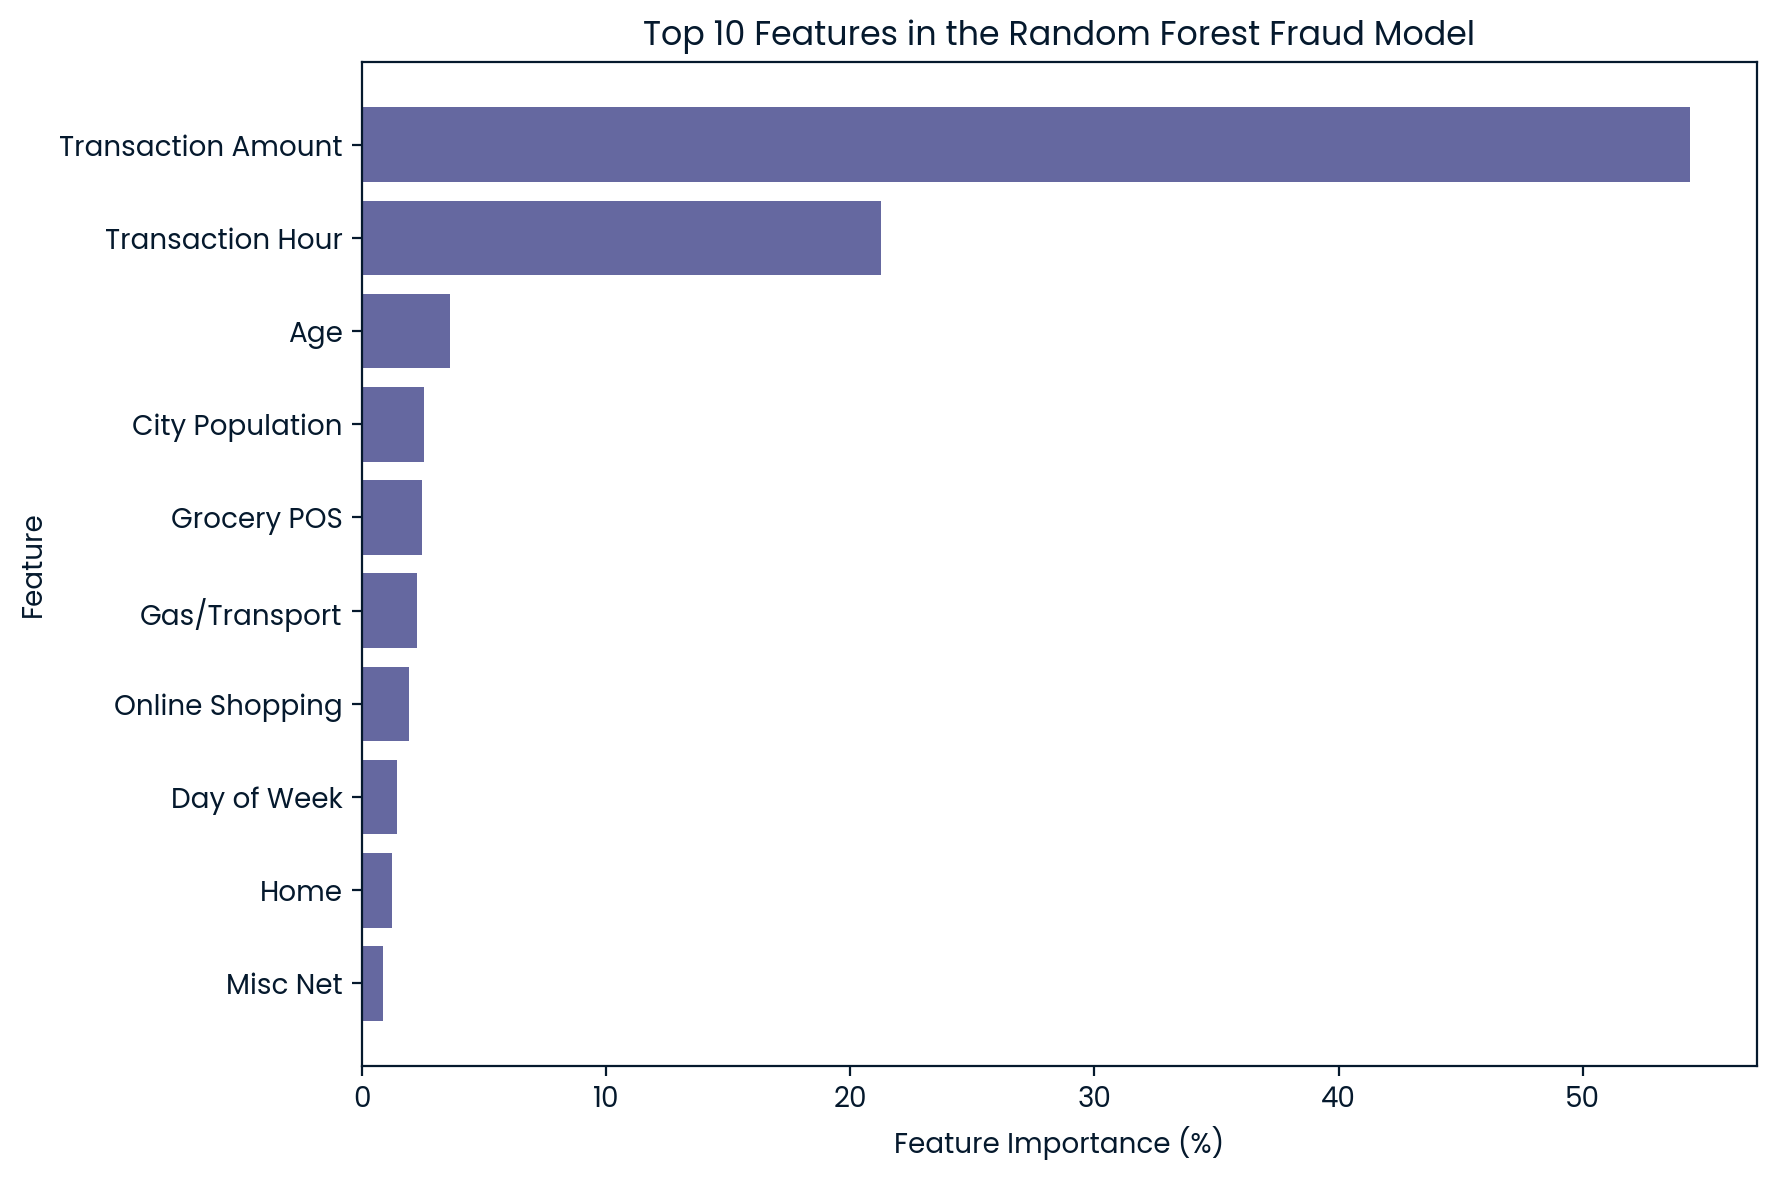

In [74]:
import matplotlib.pyplot as plt

plot_data = top_features.sort_values('Importance (%)')

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data['Feature'],
    plot_data['Importance (%)']
)

plt.xlabel('Feature Importance (%)')
plt.ylabel('Feature')
plt.title('Top 10 Features in the Random Forest Fraud Model')

plt.tight_layout()
plt.show()

In [75]:
# Final model comparison

model_comparison = pd.DataFrame({
    'Model': [
        'Baseline Logistic Regression',
        'Balanced Logistic Regression',
        'Random Forest'
    ],
    'Fraud Recall': [
        0.0000,
        0.7219,
        0.8652
    ],
    'Fraud Precision': [
        0.0000,
        0.0334,
        0.5033
    ],
    'Fraud F1 Score': [
        0.0000,
        0.0639,
        0.6364
    ],
    'PR-AUC': [
        0.2025,
        0.1289,
        0.8483
    ]
})

model_comparison

,Model,Fraud Recall,Fraud Precision,Fraud F1 Score,PR-AUC
0,Baseline Logistic Regression,0.0000,0.0000,0.0000,0.2025
1,Balanced Logistic Regression,0.7219,0.0334,0.0639,0.1289
2,Random Forest,0.8652,0.5033,0.6364,0.8483


### Model Comparison

The Random Forest substantially outperformed both logistic regression models in identifying fraudulent transactions.

Although the baseline logistic regression achieved approximately 99.5% overall accuracy, it failed to identify any fraudulent transactions, demonstrating why accuracy alone is misleading for highly imbalanced classification problems.

Applying class balancing to logistic regression improved fraud recall to approximately 72.2%, but precision remained low at approximately 3.3%, resulting in a large number of false-positive alerts.

The Random Forest achieved the strongest overall performance, identifying approximately 86.5% of fraudulent transactions while maintaining approximately 50.3% precision. It also produced a fraud-class F1 score of approximately 0.64 and a PR-AUC of approximately 0.85.

Based on these results, the Random Forest is the preferred model because it provides a substantially better balance between detecting fraudulent activity and limiting unnecessary fraud alerts.

## Threshold Selection and Business Recommendation

Fraud detection requires balancing two competing objectives: identifying as many fraudulent transactions as possible while avoiding excessive false-positive alerts that may inconvenience legitimate customers and increase investigation costs.

The Random Forest model was evaluated across probability thresholds ranging from 0.10 to 0.90. Lower thresholds produced higher fraud recall but generated substantially more false-positive alerts, while higher thresholds improved precision at the cost of missing additional fraudulent transactions.

A threshold of **0.60** provides a strong operational balance. At this threshold, the model:

- Identifies approximately **80.1% of fraudulent transactions**
- Achieves approximately **65.7% fraud precision**
- Produces an F1 score of approximately **0.72**
- Detects **285 of 356 fraudulent transactions**
- Misses **71 fraudulent transactions**
- Generates **149 false-positive alerts**

Compared with the default 0.50 threshold, increasing the threshold to 0.60 reduces false positives from 304 to 149 while still detecting the majority of fraudulent transactions.

Therefore, a probability threshold of **0.60 is recommended as the initial operating threshold**. The threshold should be monitored and adjusted over time based on the financial cost of missed fraud, customer friction caused by false alerts, and the organization's fraud-investigation capacity.

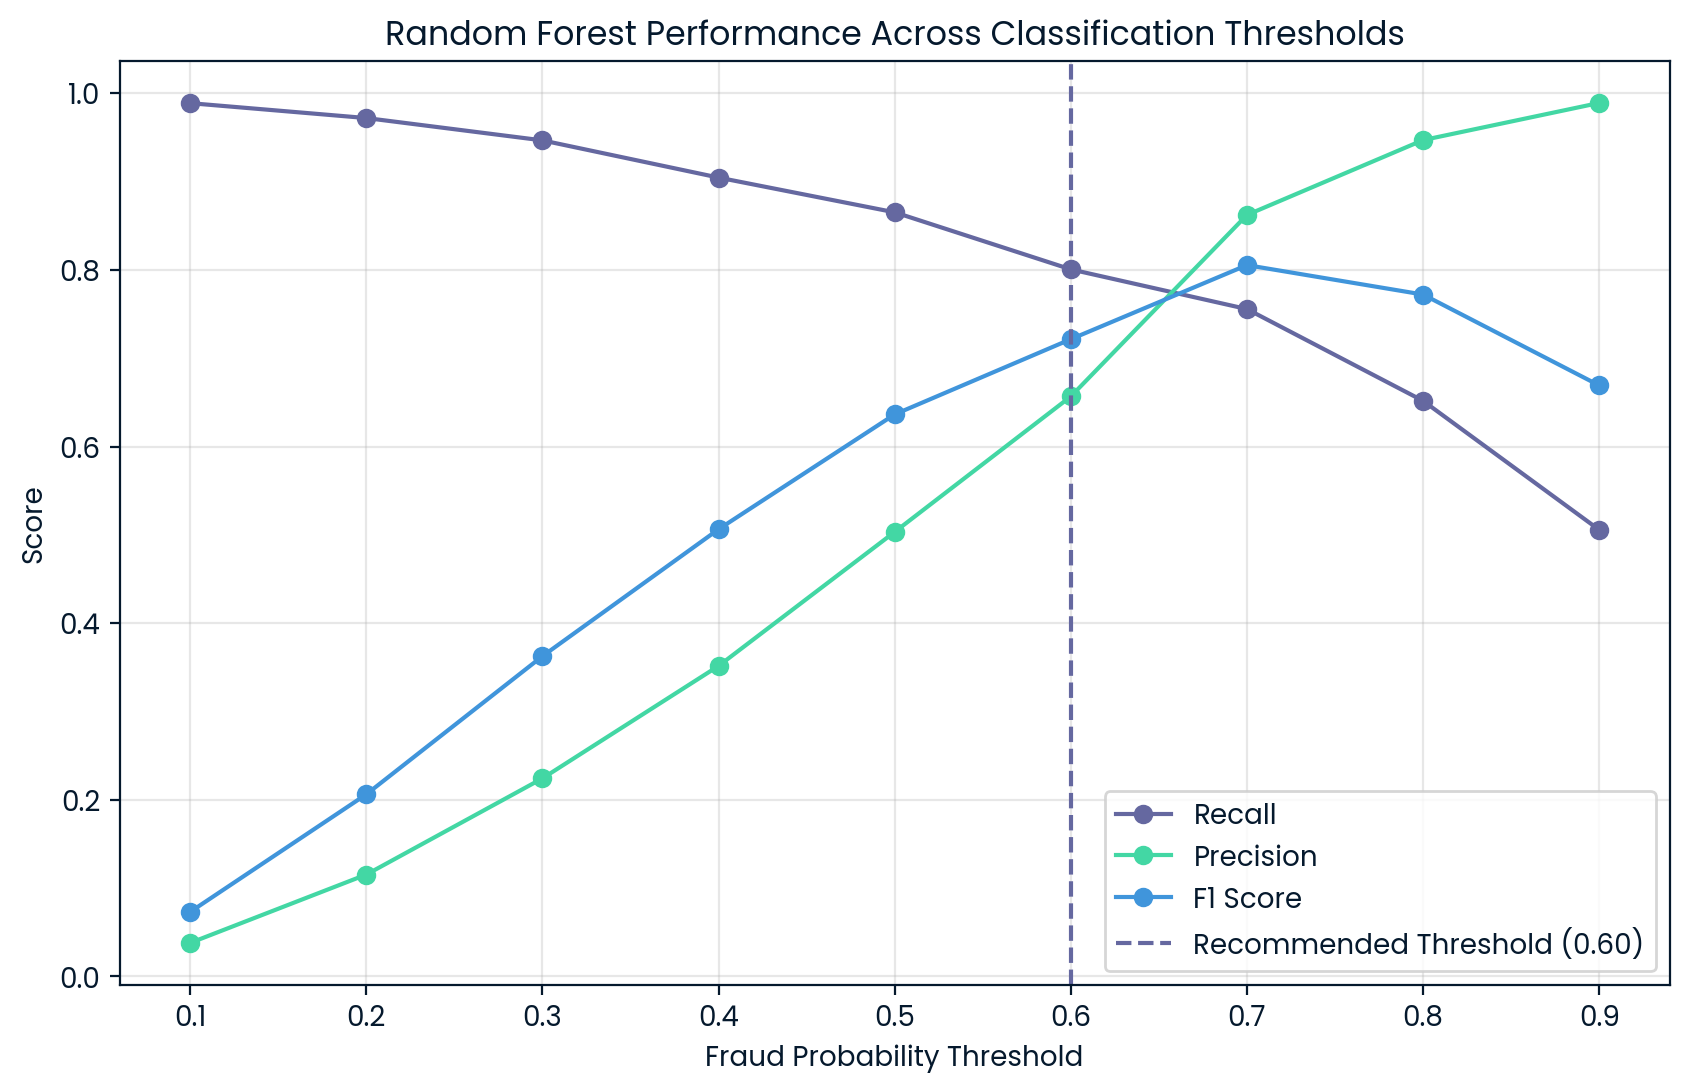

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    rf_threshold_df['Threshold'],
    rf_threshold_df['Fraud Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    rf_threshold_df['Threshold'],
    rf_threshold_df['Fraud Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    rf_threshold_df['Threshold'],
    rf_threshold_df['F1 Score'],
    marker='o',
    label='F1 Score'
)

plt.axvline(
    x=0.6,
    linestyle='--',
    label='Recommended Threshold (0.60)'
)

plt.xlabel('Fraud Probability Threshold')
plt.ylabel('Score')
plt.title('Random Forest Performance Across Classification Thresholds')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Threshold Trade-Off

The classification threshold determines how aggressively the model flags transactions as fraudulent. As the threshold increases, precision improves while recall declines, illustrating the trade-off between false-positive alerts and missed fraud.

Although the F1 score reaches its highest value near a threshold of 0.70, a **0.60 threshold is recommended** because the business objective places greater importance on identifying fraudulent transactions. At this threshold, the Random Forest detects approximately **80.1% of fraud cases** while achieving **65.7% precision**, reducing unnecessary alerts without sacrificing too much fraud detection.

This threshold should be treated as an initial operating recommendation rather than a permanent cutoff. In practice, the optimal threshold would depend on the financial cost of undetected fraud, the cost of reviewing false-positive alerts, and the organization's risk tolerance.

## Key Findings

The analysis identified several patterns associated with fraudulent credit card transactions:

1. **Fraud is rare but operationally important.** Only approximately **0.52% of the 339,607 transactions** in the dataset were fraudulent, demonstrating the severe class imbalance present in fraud detection problems.

2. **Transaction amount is the strongest predictor of fraud.** Random Forest feature importance indicates that transaction amount accounts for approximately **54% of the model's predictive importance**. Exploratory analysis also showed substantially higher fraud rates among larger transactions.

3. **Transaction timing provides meaningful predictive information.** Transaction hour was the second-most important feature, accounting for approximately **21% of model importance.** Fraud rates were notably higher during late-night hours.

4. **Merchant category contributes additional fraud signals.** Categories such as online shopping, grocery point-of-sale, and miscellaneous online transactions exhibited higher fraud rates than several other merchant categories.

5. **Age is statistically associated with fraud, but the practical relationship is weak.** The chi-square test found a statistically significant relationship between age group and fraud status; however, Cramér's V was only **0.0237**, indicating a very weak association.

6. **Accuracy is misleading for highly imbalanced fraud data.** The baseline logistic regression achieved approximately **99.5% accuracy** while identifying none of the fraudulent transactions.

7. **Random Forest substantially improved fraud detection.** At the default 0.50 threshold, the model achieved approximately **86.5% recall**, **50.3% precision**, and a **0.64 fraud-class F1 score**, substantially outperforming the logistic regression models.

8. **Classification thresholds create an important business trade-off.** A threshold of **0.60** provides a practical balance between fraud detection and false-positive alerts, achieving approximately **80.1% recall** and **65.7% precision**.

## Business Recommendations

Based on the analysis and model results, the following actions are recommended:

### 1. Deploy the Random Forest as the preferred fraud-screening model

The Random Forest provided the strongest performance among the evaluated models and was substantially more effective at identifying fraudulent transactions than either logistic regression approach.

### 2. Use a 0.60 probability threshold as an initial operating point

A 0.60 classification threshold provides a reasonable balance between fraud detection and false-positive alerts. At this threshold, the model identifies approximately 80% of fraudulent transactions while maintaining approximately 66% precision.

Rather than automatically declining every transaction exceeding the threshold, transactions could initially be routed for additional verification or fraud review.

### 3. Prioritize high-value transactions in fraud monitoring

Transaction amount was the strongest predictor in the Random Forest model. Higher-value transactions should therefore receive increased scrutiny, particularly when combined with other risk indicators.

### 4. Incorporate transaction timing into fraud controls

Transaction hour was the second-most influential model feature. Transactions occurring during higher-risk late-night periods may warrant additional authentication when combined with other suspicious characteristics.

### 5. Use multiple risk factors rather than demographic characteristics alone

Although customer age showed a statistically significant relationship with fraud, the effect size was very small. Fraud controls should therefore rely primarily on transactional behavior and multiple combined risk indicators rather than customer age alone.

### 6. Continuously monitor model performance

Fraud behavior changes over time. Model recall, precision, false-positive rates, and threshold performance should be monitored regularly, with the model retrained as new transaction and fraud data become available.

## Limitations

Several limitations should be considered when interpreting these results.

First, the analysis is based on historical transaction data and may not represent future fraud patterns. Fraud strategies evolve over time, which can reduce model performance if the model is not regularly retrained.

Second, the dataset contains a highly imbalanced target variable, with fraudulent transactions representing only approximately 0.52% of observations. Although evaluation metrics such as recall, precision, F1 score, and PR-AUC were used to address this issue, rare-event prediction remains challenging.

Third, feature importance from the Random Forest indicates which variables contribute to model predictions but does not establish that those variables cause fraudulent activity.

Fourth, the recommended 0.60 threshold was selected using model-performance trade-offs rather than actual financial cost data. A production implementation should incorporate the monetary cost of missed fraud, false-positive investigations, customer friction, and operational review capacity.

Finally, the model was evaluated using a train-test split of the available historical data. Additional validation using future or out-of-time transaction data would provide stronger evidence of the model's ability to generalize to new fraud patterns.

## Conclusion

This project demonstrates how SQL, Python, statistical analysis, and machine learning can be combined to investigate and predict credit card fraud.

Exploratory analysis identified transaction amount, merchant category, transaction timing, geography, and customer characteristics as potential fraud indicators. Statistical testing further demonstrated that statistically significant relationships do not necessarily imply strong practical effects.

The modeling process also highlighted the limitations of accuracy when evaluating highly imbalanced classification problems. While the baseline logistic regression achieved high overall accuracy, it failed to identify fraudulent transactions. A balanced logistic regression improved fraud recall but generated a large number of false positives.

The Random Forest provided the strongest overall performance. At the default threshold, it identified approximately 86.5% of fraudulent transactions, while threshold analysis demonstrated how model predictions can be adjusted according to business priorities.

A threshold of 0.60 is recommended as an initial operating point, providing approximately 80.1% fraud recall and 65.7% precision while substantially reducing false-positive alerts.

Overall, the results demonstrate that effective fraud detection requires more than maximizing model accuracy. Successful implementation requires balancing predictive performance with the financial and operational consequences of missed fraud and false-positive alerts.